In [1]:
import pandas as pd 
import numpy as np 
df=pd.read_csv("../data/postings.csv")
print("shape",df.shape)
print("\ncolumns",df.columns.tolist())
print("\n first 5 rows:")
df.head()

shape (123849, 31)

columns ['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips']

 first 5 rows:


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


In [3]:
print("missing values:\n",df.isnull().sum())
print("\nData types:\n",df.dtypes)
print('\nBasic stats:\n',df.describe())

missing values:
 job_id                             0
company_name                    1719
title                              0
description                        7
max_salary                     94056
pay_period                     87776
location                           0
company_id                      1717
views                           1689
med_salary                    117569
min_salary                     94056
formatted_work_type                0
applies                       100529
original_listed_time               0
remote_allowed                108603
job_posting_url                    0
application_url                36665
application_type                   0
expiry                             0
closed_time                   122776
formatted_experience_level     29409
skills_desc                   121410
listed_time                        0
posting_domain                 39968
sponsored                          0
work_type                          0
currency             

In [4]:
print("total job postings:",len(df))
print("unique companies:",df['company_name'].nunique())
print("unique locations:",df['location'].nunique())

total job postings: 123849
unique companies: 24428
unique locations: 8526


In [5]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('../data/postings.csv')
print("Original shape:", df.shape)

Original shape: (123849, 31)


In [6]:
# Drop columns we don't need
cols_to_drop = [
    'job_id', 'company_id', 'job_posting_url', 'application_url',
    'application_type', 'posting_domain', 'sponsored', 'zip_code',
    'fips', 'expiry', 'closed_time', 'currency',
    'compensation_type', 'pay_period'
]

df = df.drop(columns=cols_to_drop)
print("After dropping useless columns:", df.shape)

After dropping useless columns: (123849, 17)


In [7]:
# See missing values clearly
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_report[missing_report['Missing Count'] > 0])

                            Missing Count  Missing %
skills_desc                        121410      98.03
med_salary                         117569      94.93
remote_allowed                     108603      87.69
applies                            100529      81.17
min_salary                          94056      75.94
max_salary                          94056      75.94
normalized_salary                   87776      70.87
formatted_experience_level          29409      23.75
company_name                         1719       1.39
views                                1689       1.36
description                             7       0.01


In [8]:
# 1. Salary — use normalized_salary as master salary column
df['salary'] = df['normalized_salary']

# Fill missing salary with median
df['salary'] = df['salary'].fillna(df['salary'].median())

# 2. Location — fill missing with 'Unknown'
df['location'] = df['location'].fillna('Unknown')

# 3. Company name — fill missing with 'Unknown Company'
df['company_name'] = df['company_name'].fillna('Unknown Company')

# 4. Remote allowed — fill missing with 0 (not remote)
df['remote_allowed'] = df['remote_allowed'].fillna(0)

# 5. Skills desc — fill missing with empty string
df['skills_desc'] = df['skills_desc'].fillna('')

# 6. Description — fill missing with empty string  
df['description'] = df['description'].fillna('')

# 7. Experience level — fill missing with 'Not Specified'
df['formatted_experience_level'] = df['formatted_experience_level'].fillna('Not Specified')

# 8. Drop rows where title is missing (can't analyze without job title)
df = df.dropna(subset=['title'])

print("After fixing missing values:", df.shape)
print("\nRemaining missing values:\n", df.isnull().sum())

After fixing missing values: (123849, 18)

Remaining missing values:
 company_name                       0
title                              0
description                        0
max_salary                     94056
location                           0
views                           1689
med_salary                    117569
min_salary                     94056
formatted_work_type                0
applies                       100529
original_listed_time               0
remote_allowed                     0
formatted_experience_level         0
skills_desc                        0
listed_time                        0
work_type                          0
normalized_salary              87776
salary                             0
dtype: int64


In [9]:
# 1. Extract City from Location
# Location format is usually "City, State" or "City, Country"
df['city'] = df['location'].str.split(',').str[0].str.strip()
df['state'] = df['location'].str.split(',').str[1].str.strip()

# 2. Salary bracket (Low / Mid / High)
def salary_bracket(sal):
    if sal < 50000:
        return 'Low'
    elif sal < 100000:
        return 'Mid'
    else:
        return 'High'

df['salary_bracket'] = df['salary'].apply(salary_bracket)

# 3. Is Data Role? (Filter relevant jobs)
data_keywords = ['data', 'analyst', 'scientist', 'analytics', 
                 'machine learning', 'ml', 'ai', 'business intelligence',
                 'bi', 'python', 'sql', 'tableau', 'power bi']

df['is_data_role'] = df['title'].str.lower().str.contains(
    '|'.join(data_keywords), na=False
)

print("Total data roles found:", df['is_data_role'].sum())

# 4. Convert timestamps to readable dates
df['listed_date'] = pd.to_datetime(df['listed_time'], unit='ms', errors='coerce')
df['year'] = df['listed_date'].dt.year
df['month'] = df['listed_date'].dt.month

print("\nNew columns added successfully!")

Total data roles found: 18731

New columns added successfully!


In [10]:
# Dataset 1 — Full cleaned dataset
df_clean = df.copy()
df_clean.to_csv('../data/postings_cleaned.csv', index=False)
print("Full cleaned dataset saved:", df_clean.shape)

# Dataset 2 — Data roles only (this is your main analysis dataset)
df_data_roles = df[df['is_data_role'] == True].copy()
df_data_roles.to_csv('../data/data_roles_only.csv', index=False)
print("Data roles dataset saved:", df_data_roles.shape)

Full cleaned dataset saved: (123849, 25)
Data roles dataset saved: (18731, 25)


In [11]:
print("=== FINAL DATA QUALITY REPORT ===")
print(f"Total rows (cleaned): {len(df_clean)}")
print(f"Total data roles found: {len(df_data_roles)}")
print(f"Columns remaining: {df_clean.columns.tolist()}")
print(f"\nSalary brackets distribution:\n{df_clean['salary_bracket'].value_counts()}")
print(f"\nExperience levels:\n{df_clean['formatted_experience_level'].value_counts()}")
print(f"\nRemote vs Office:\n{df_clean['remote_allowed'].value_counts()}")
print(f"\nTop 10 cities:\n{df_clean['city'].value_counts().head(10)}")

=== FINAL DATA QUALITY REPORT ===
Total rows (cleaned): 123849
Total data roles found: 18731
Columns remaining: ['company_name', 'title', 'description', 'max_salary', 'location', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'formatted_experience_level', 'skills_desc', 'listed_time', 'work_type', 'normalized_salary', 'salary', 'city', 'state', 'salary_bracket', 'is_data_role', 'listed_date', 'year', 'month']

Salary brackets distribution:
salary_bracket
Mid     101449
High     13997
Low       8403
Name: count, dtype: int64

Experience levels:
formatted_experience_level
Mid-Senior level    41489
Entry level         36708
Not Specified       29409
Associate            9826
Director             3746
Internship           1449
Executive            1222
Name: count, dtype: int64

Remote vs Office:
remote_allowed
0.0    108603
1.0     15246
Name: count, dtype: int64

Top 10 cities:
city
United States    8125
New York         3

In [12]:
print("Data roles found:", len(df_data_roles))
print("Columns:", df_clean.columns.tolist())
print("Missing values left:", df_clean.isnull().sum().sum())

Data roles found: 18731
Columns: ['company_name', 'title', 'description', 'max_salary', 'location', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'formatted_experience_level', 'skills_desc', 'listed_time', 'work_type', 'normalized_salary', 'salary', 'city', 'state', 'salary_bracket', 'is_data_role', 'listed_date', 'year', 'month']
Missing values left: 509040


EDA

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Style setup — makes your charts look professional
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Blues_r")

# Load your data roles dataset
df = pd.read_csv('../data/data_roles_only.csv')
print("Data roles loaded:", df.shape)
print("Entry level jobs:", len(df[df['formatted_experience_level'] == 'Entry level']))

Data roles loaded: (18731, 25)
Entry level jobs: 5206


 Top 20 Most Demanded Skills (Most Important!)

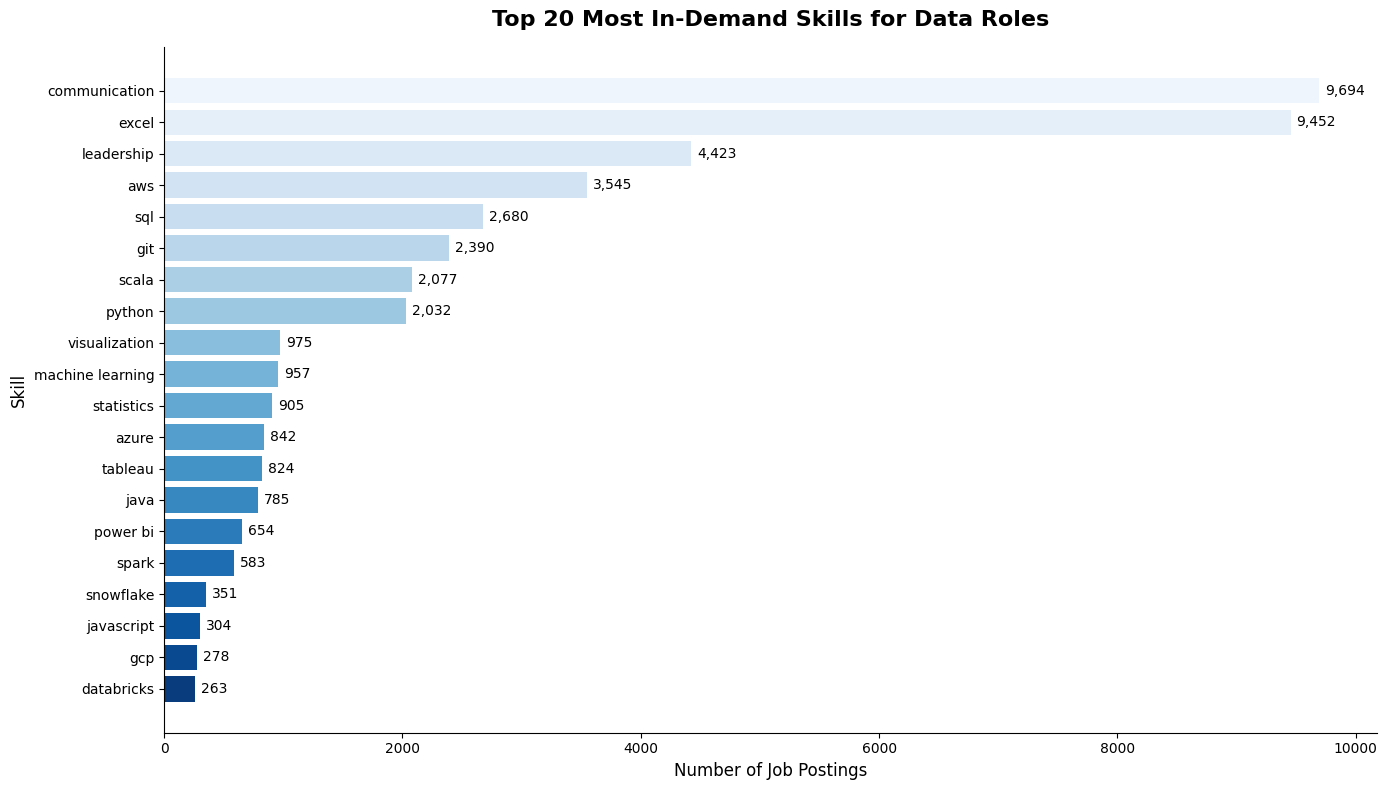


💡 INSIGHT: Top 3 skills are communication , excel and leadership


In [15]:
# Extract skills from skills_desc column
all_skills = []

# Common data skills to look for
skill_keywords = [
    'python', 'sql', 'excel', 'tableau', 'power bi', 'r programming', 'spark',
    'hadoop', 'machine learning', 'deep learning', 'tensorflow', 'pytorch',
    'scikit', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'git',
    'aws', 'azure', 'gcp', 'docker', 'kubernetes', 'airflow',
    'kafka', 'mongodb', 'postgresql', 'mysql', 'snowflake', 'databricks',
    'looker', 'dbt', 'scala', 'java', 'javascript', 'nlp',
    'statistics', 'visualization', 'communication', 'leadership'
]

# Search through skills_desc + description columns
for _, row in df.iterrows():
    text = str(row['skills_desc']).lower() + ' ' + str(row['description']).lower()
    for skill in skill_keywords:
        if skill in text:
            all_skills.append(skill.strip())

# Count and plot
skill_counts = Counter(all_skills)
skill_df = pd.DataFrame(skill_counts.most_common(20),
                         columns=['Skill', 'Count'])

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(skill_df['Skill'][::-1],
               skill_df['Count'][::-1],
               color=sns.color_palette("Blues_r", 20))

ax.set_title('Top 20 Most In-Demand Skills for Data Roles',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Number of Job Postings', fontsize=12)
ax.set_ylabel('Skill', fontsize=12)

# Add value labels
for i, (val, name) in enumerate(zip(skill_df['Count'][::-1],
                                     skill_df['Skill'][::-1])):
    ax.text(val + 50, i, f'{val:,}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/chart1_top_skills.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 INSIGHT: Top 3 skills are",
      skill_df['Skill'][0], ",",
      skill_df['Skill'][1], "and",
      skill_df['Skill'][2])

Top 15 Cities for Data Jobs

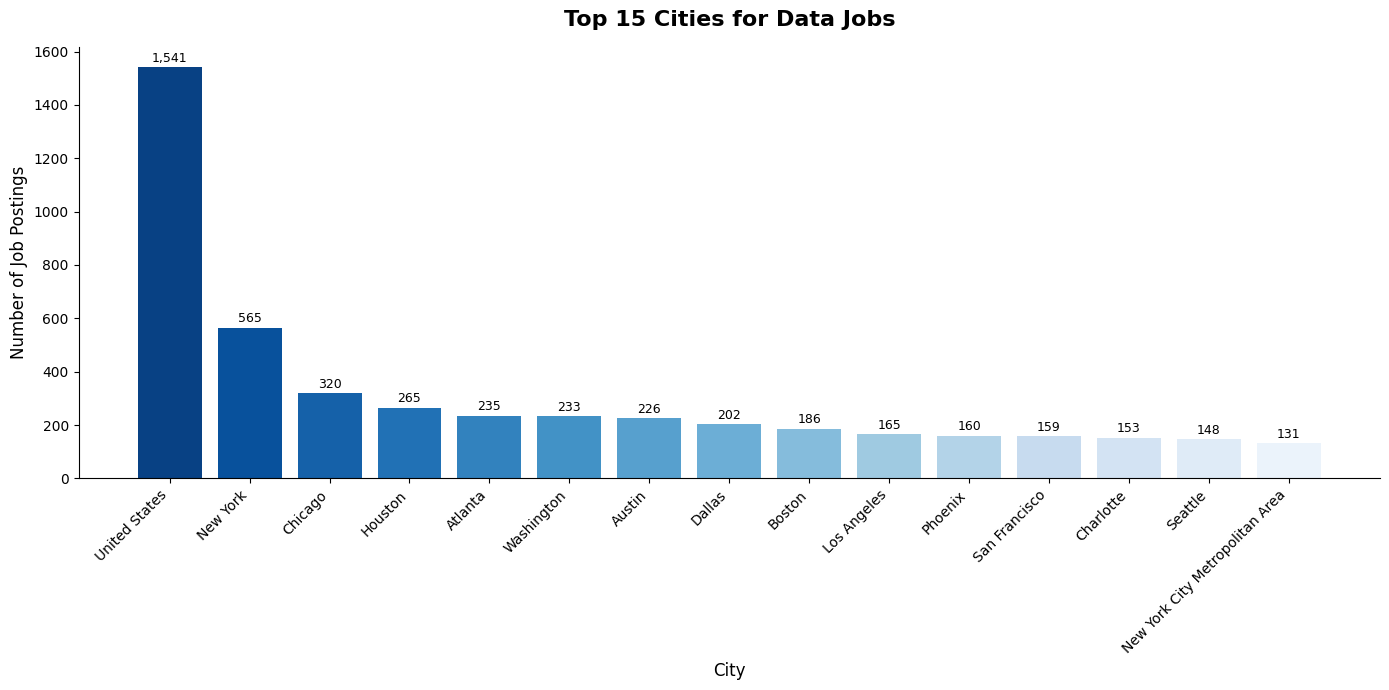


💡 INSIGHT: Top city is United States with 1541 job postings


In [16]:
# Top cities
city_counts = df['city'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.bar(city_counts.index,
              city_counts.values,
              color=sns.color_palette("Blues_r", 15))

ax.set_title('Top 15 Cities for Data Jobs',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('City', fontsize=12)
ax.set_ylabel('Number of Job Postings', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for bar, val in zip(bars, city_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 20,
            f'{val:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/chart2_top_cities.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 INSIGHT: Top city is", city_counts.index[0],
      "with", city_counts.values[0], "job postings")

Salary Distribution

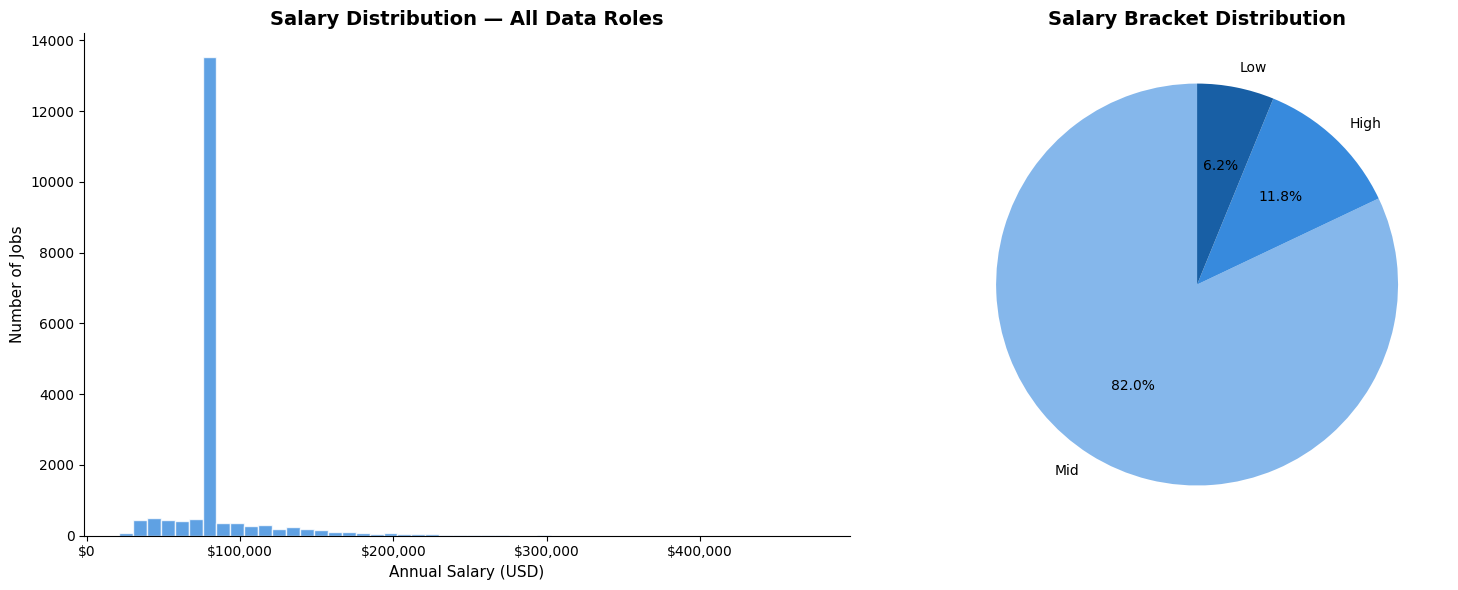


💡 INSIGHT: Median salary for data roles: $ 81500.0
Entry level median: $ 81500.0


In [17]:
# Filter realistic salaries (remove outliers)
salary_df = df[(df['salary'] > 20000) & (df['salary'] < 500000)].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left — Histogram
axes[0].hist(salary_df['salary'],
             bins=50,
             color='#378ADD',
             edgecolor='white',
             alpha=0.8)
axes[0].set_title('Salary Distribution — All Data Roles',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Annual Salary (USD)', fontsize=11)
axes[0].set_ylabel('Number of Jobs', fontsize=11)
axes[0].xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Right — Salary bracket pie
bracket_counts = df['salary_bracket'].value_counts()
colors = ['#85B7EB', '#378ADD', '#185FA5']
axes[1].pie(bracket_counts.values,
            labels=bracket_counts.index,
            autopct='%1.1f%%',
            colors=colors,
            startangle=90)
axes[1].set_title('Salary Bracket Distribution',
                   fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/chart3_salary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 INSIGHT: Median salary for data roles: $",
      round(salary_df['salary'].median(), 0))
print("Entry level median: $",
      round(salary_df[salary_df['formatted_experience_level']
                      == 'Entry level']['salary'].median(), 0))

Remote vs Office

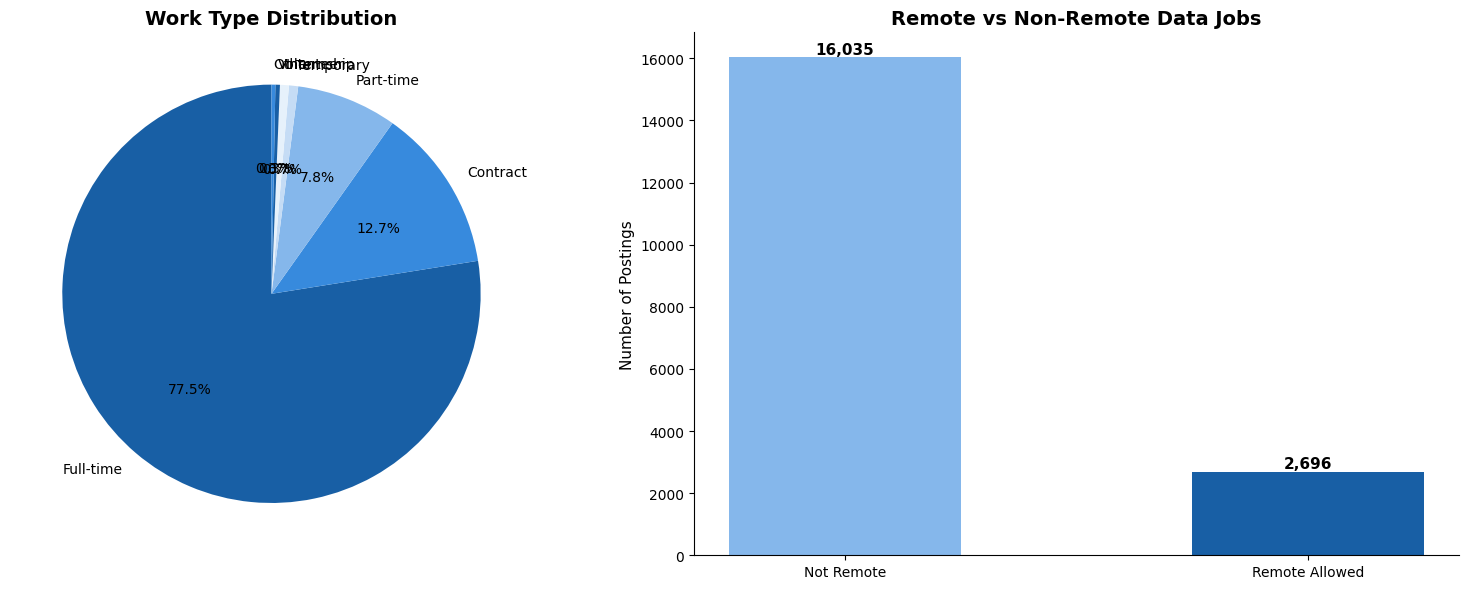


💡 INSIGHT: Remote allowed jobs: 2696 out of 18731


In [18]:
# Work type distribution
work_counts = df['formatted_work_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left — Work type
colors_work = ['#185FA5', '#378ADD', '#85B7EB', '#C5DCF5', '#E6F1FB']
axes[0].pie(work_counts.values,
            labels=work_counts.index,
            autopct='%1.1f%%',
            colors=colors_work[:len(work_counts)],
            startangle=90)
axes[0].set_title('Work Type Distribution',
                   fontsize=14, fontweight='bold')

# Right — Remote allowed
remote_counts = df['remote_allowed'].value_counts()
remote_labels = ['Not Remote', 'Remote Allowed']
axes[1].bar(remote_labels,
            remote_counts.values,
            color=['#85B7EB', '#185FA5'],
            width=0.5)
axes[1].set_title('Remote vs Non-Remote Data Jobs',
                   fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Postings', fontsize=11)

for i, val in enumerate(remote_counts.values):
    axes[1].text(i, val + 100, f'{val:,}',
                 ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/chart4_remote.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 INSIGHT: Remote allowed jobs:",
      remote_counts.get(1.0, 0), "out of", len(df))

Top Companies Hiring Data Roles

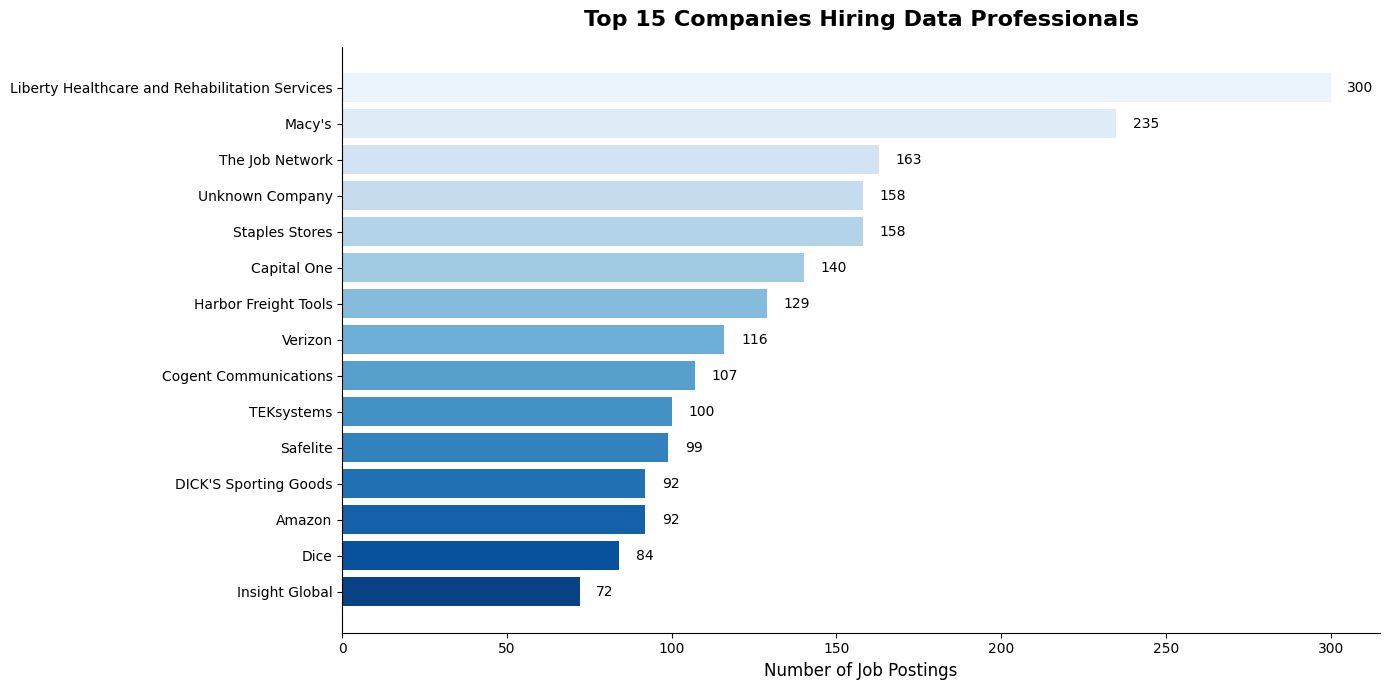


💡 INSIGHT: Top hiring company is Liberty Healthcare and Rehabilitation Services with 300 postings


In [19]:
# Top 15 companies
company_counts = df['company_name'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(company_counts.index[::-1],
               company_counts.values[::-1],
               color=sns.color_palette("Blues_r", 15))

ax.set_title('Top 15 Companies Hiring Data Professionals',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Number of Job Postings', fontsize=12)

for i, val in enumerate(company_counts.values[::-1]):
    ax.text(val + 5, i, f'{val:,}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/chart5_companies.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 INSIGHT: Top hiring company is",
      company_counts.index[0],
      "with", company_counts.values[0], "postings")

EDA 2

Salary by Experience Level

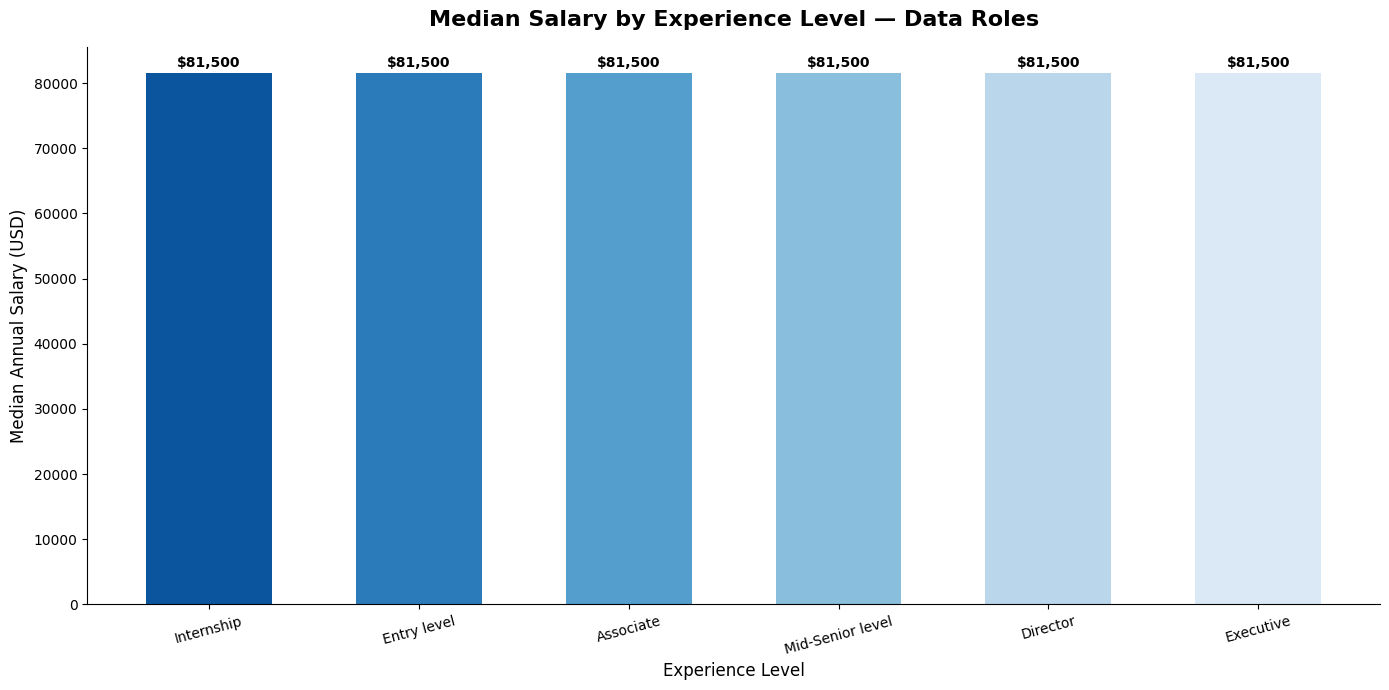


💡 INSIGHT: Internship median salary: $ 81500.0
Entry level median salary: $ 81500.0
Mid-Senior median salary: $ 81500.0
Executive median salary: $ 81500.0


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('../data/data_roles_only.csv')

# Filter valid salaries
salary_df = df[(df['salary'] > 20000) & 
               (df['salary'] < 500000)].copy()

# Experience order
exp_order = ['Internship', 'Entry level', 'Associate', 
             'Mid-Senior level', 'Director', 'Executive']

exp_salary = salary_df[
    salary_df['formatted_experience_level'].isin(exp_order)
].groupby('formatted_experience_level')['salary'].median().reindex(exp_order).dropna()

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.bar(exp_salary.index, 
              exp_salary.values,
              color=sns.color_palette("Blues_r", len(exp_salary)),
              width=0.6)

ax.set_title('Median Salary by Experience Level — Data Roles',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Experience Level', fontsize=12)
ax.set_ylabel('Median Annual Salary (USD)', fontsize=12)
plt.xticks(rotation=15)

for bar, val in zip(bars, exp_salary.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1000,
            f'${val:,.0f}', ha='center', 
            fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/chart6_salary_by_exp.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 INSIGHT: Internship median salary: $",
      exp_salary.get('Internship', 0))
print("Entry level median salary: $",
      exp_salary.get('Entry level', 0))
print("Mid-Senior median salary: $",
      exp_salary.get('Mid-Senior level', 0))
print("Executive median salary: $",
      exp_salary.get('Executive', 0))

Top 20 Most Common Job Titles

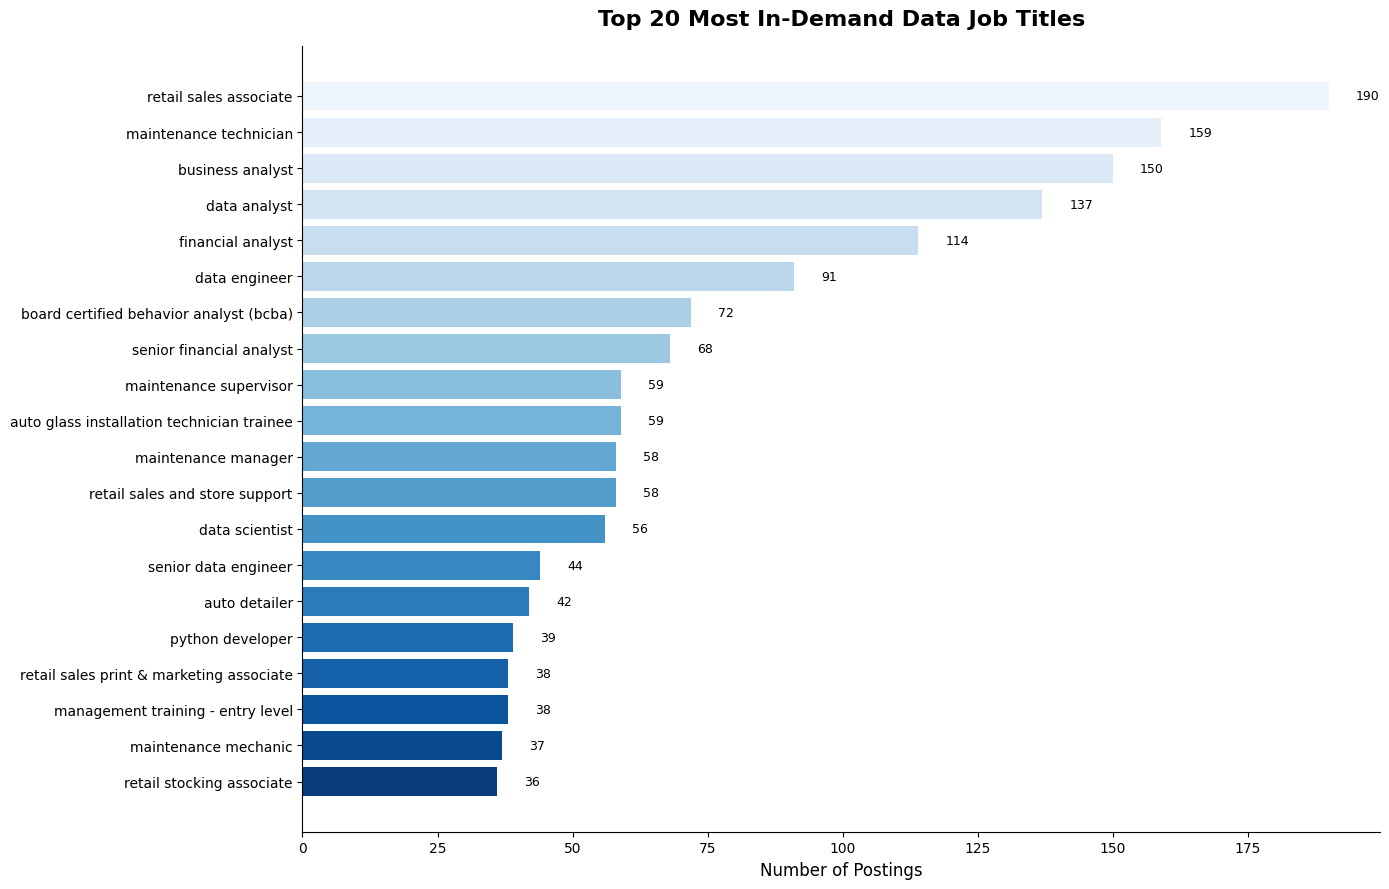


💡 INSIGHT: Most in demand title is: retail sales associate with 190 postings
Top 5 titles: ['retail sales associate', 'maintenance technician', 'business analyst', 'data analyst', 'financial analyst']


In [22]:
# Clean job titles
title_counts = df['title'].str.lower().str.strip().value_counts().head(20)

fig, ax = plt.subplots(figsize=(14, 9))
bars = ax.barh(title_counts.index[::-1],
               title_counts.values[::-1],
               color=sns.color_palette("Blues_r", 20))

ax.set_title('Top 20 Most In-Demand Data Job Titles',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Number of Postings', fontsize=12)

for i, val in enumerate(title_counts.values[::-1]):
    ax.text(val + 5, i, f'{val:,}', 
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/chart7_job_titles.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 INSIGHT: Most in demand title is:",
      title_counts.index[0], "with", 
      title_counts.values[0], "postings")
print("Top 5 titles:", title_counts.index[:5].tolist())

Remote vs Non-Remote Salary Comparison

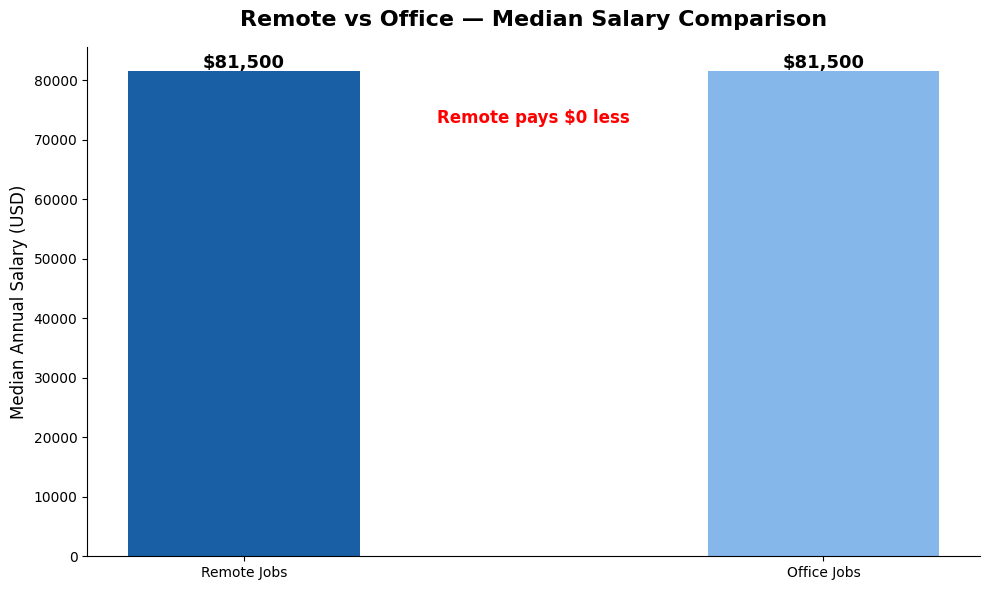


💡 INSIGHT: Remote median salary: $ 81500.0
Office median salary: $ 81500.0
Difference: $ 0.0 more for office


In [24]:
# Remote salary comparison
remote_salary = salary_df[salary_df['remote_allowed'] == 1.0]['salary'].median()
office_salary = salary_df[salary_df['remote_allowed'] == 0.0]['salary'].median()

fig, ax = plt.subplots(figsize=(10, 6))
categories = ['Remote Jobs', 'Office Jobs']
salaries = [remote_salary, office_salary]
colors = ['#185FA5', '#85B7EB']

bars = ax.bar(categories, salaries, color=colors, width=0.4)

ax.set_title('Remote vs Office — Median Salary Comparison',
             fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Median Annual Salary (USD)', fontsize=12)

for bar, val in zip(bars, salaries):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 500,
            f'${val:,.0f}', ha='center',
            fontsize=13, fontweight='bold')

# Add difference annotation
diff = remote_salary - office_salary
ax.annotate(f'Remote pays ${abs(diff):,.0f} {"more" if diff > 0 else "less"}',
            xy=(0.5, 0.85), xycoords='axes fraction',
            ha='center', fontsize=12,
            color='green' if diff > 0 else 'red',
            fontweight='bold')

plt.tight_layout()
plt.savefig('../data/chart8_remote_salary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 INSIGHT: Remote median salary: $", remote_salary)
print("Office median salary: $", office_salary)
print("Difference: $", abs(diff), 
      "more for", "remote" if diff > 0 else "office")

 Monthly Hiring Trend

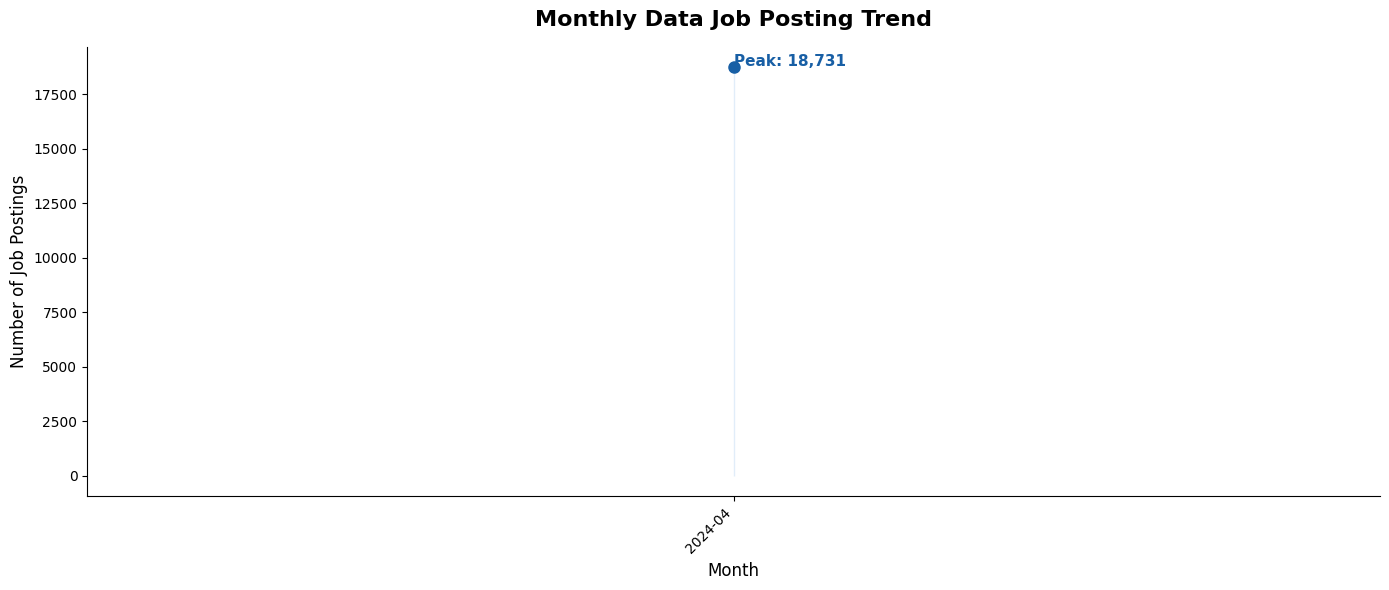


💡 INSIGHT: Peak hiring month: 2024-04
Lowest hiring month: 2024-04


In [25]:
# Convert and analyze hiring trends
df['listed_date'] = pd.to_datetime(df['listed_date'], errors='coerce')
df['month_year'] = df['listed_date'].dt.to_period('M')

monthly = df.groupby('month_year').size().reset_index(name='count')
monthly = monthly.dropna()
monthly = monthly.tail(12)  # Last 12 months

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly['month_year'].astype(str),
        monthly['count'],
        color='#185FA5',
        linewidth=2.5,
        marker='o',
        markersize=8)

ax.fill_between(monthly['month_year'].astype(str),
                monthly['count'],
                alpha=0.15,
                color='#378ADD')

ax.set_title('Monthly Data Job Posting Trend',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Job Postings', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Mark peak month
peak_idx = monthly['count'].idxmax()
peak_month = monthly.loc[peak_idx, 'month_year']
peak_val = monthly.loc[peak_idx, 'count']
ax.annotate(f'Peak: {peak_val:,}',
            xy=(str(peak_month), peak_val),
            xytext=(str(peak_month), peak_val + 50),
            fontsize=11, color='#185FA5',
            fontweight='bold')

plt.tight_layout()
plt.savefig('../data/chart9_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 INSIGHT: Peak hiring month:", peak_month)
print("Lowest hiring month:", 
      monthly.loc[monthly['count'].idxmin(), 'month_year'])

Applies vs Views — Job Popularity

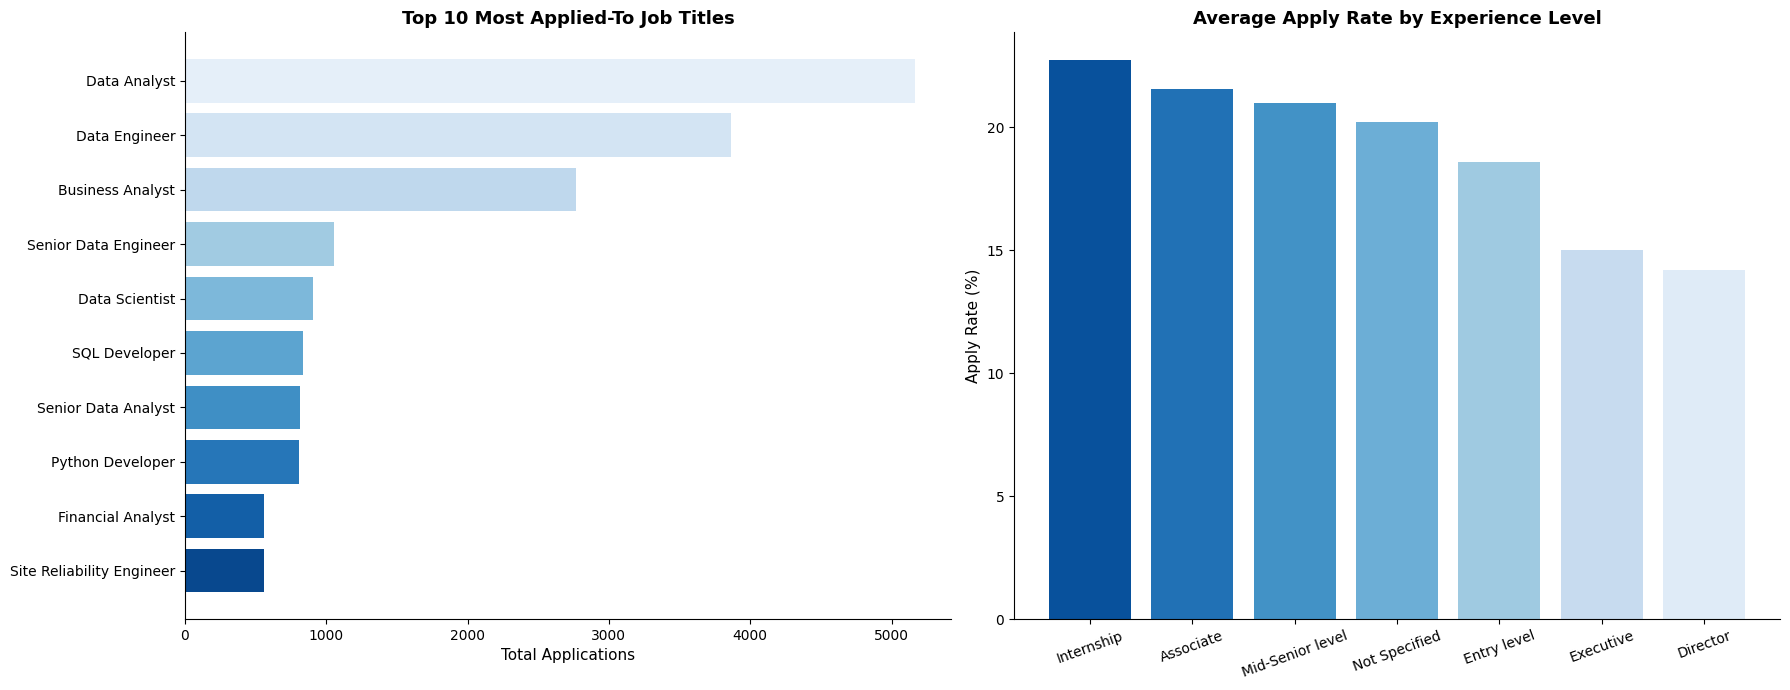


💡 INSIGHT: Most applied job title: Data Analyst
Highest apply rate experience level: Internship


In [26]:
# Most applied vs most viewed jobs
popular = df[(df['applies'] > 0) & 
             (df['views'] > 0)].copy()

popular['apply_rate'] = (popular['applies'] / 
                          popular['views'] * 100).round(2)

# Top 10 most applied job titles
top_applied = popular.groupby('title')['applies'].sum().sort_values(
    ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left — Most applied
axes[0].barh(top_applied.index[::-1],
             top_applied.values[::-1],
             color=sns.color_palette("Blues_r", 10))
axes[0].set_title('Top 10 Most Applied-To Job Titles',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Applications', fontsize=11)

# Right — Apply rate by experience
exp_apply = popular.groupby(
    'formatted_experience_level')['apply_rate'].mean().sort_values(
    ascending=False)

axes[1].bar(exp_apply.index,
            exp_apply.values,
            color=sns.color_palette("Blues_r", len(exp_apply)))
axes[1].set_title('Average Apply Rate by Experience Level',
                   fontsize=13, fontweight='bold')
axes[1].set_ylabel('Apply Rate (%)', fontsize=11)
plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig('../data/chart10_popularity.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 INSIGHT: Most applied job title:",
      top_applied.index[0])
print("Highest apply rate experience level:",
      exp_apply.index[0])

SALARY CHECKS

In [27]:
df = pd.read_csv('../data/data_roles_only.csv')
print("Unique salary values:", df['salary'].nunique())
print("Salary value counts top 5:\n", df['salary'].value_counts().head())
print("Normalized salary unique:", df['normalized_salary'].nunique())
print("Min salary unique:", df['min_salary'].nunique())
print("Max salary unique:", df['max_salary'].nunique())

Unique salary values: 1984
Salary value counts top 5:
 salary
81500.0     13097
130000.0       63
70000.0        62
41600.0        60
100000.0       57
Name: count, dtype: int64
Normalized salary unique: 1984
Min salary unique: 1325
Max salary unique: 1512


In [28]:
print("listed_time sample:\n", df['listed_time'].head(10))
df['listed_date_fixed'] = pd.to_datetime(df['listed_time'], unit='ms', errors='coerce')
print("\nFixed date sample:\n", df['listed_date_fixed'].head(10))
print("Unique months:", df['listed_date_fixed'].dt.to_period('M').nunique())

listed_time sample:
 0    1.712654e+12
1    1.713208e+12
2    1.712635e+12
3    1.713509e+12
4    1.712904e+12
5    1.712904e+12
6    1.713494e+12
7    1.712862e+12
8    1.712643e+12
9    1.712347e+12
Name: listed_time, dtype: float64

Fixed date sample:
 0   2024-04-09 09:08:18
1   2024-04-15 19:12:39
2   2024-04-09 03:54:38
3   2024-04-19 06:42:23
4   2024-04-12 06:46:24
5   2024-04-12 06:46:24
6   2024-04-19 02:31:59
7   2024-04-11 19:08:11
8   2024-04-09 06:01:46
9   2024-04-05 20:01:32
Name: listed_date_fixed, dtype: datetime64[ms]
Unique months: 1


In [29]:
data_title_keywords = ['data', 'analyst', 'analytics', 'scientist', 'machine learning', 'ml', 'intelligence', 'statistician', 'quantitative']
pattern = '|'.join(data_title_keywords)
df_data_strict = df[df['title'].str.lower().str.contains(pattern, na=False)].copy()
print("Strict data roles count:", len(df_data_strict))
print("\nTop 10 titles:\n", df_data_strict['title'].value_counts().head(10))

Strict data roles count: 8159

Top 10 titles:
 title
Business Analyst                           146
Data Analyst                               137
Financial Analyst                          113
Data Engineer                               90
Board Certified Behavior Analyst (BCBA)     72
Senior Financial Analyst                    68
Data Scientist                              56
Senior Data Engineer                        44
Senior Business Analyst                     34
Database Administrator                      33
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np

# Load original
df = pd.read_csv('../data/data_roles_only.csv')

# Fix 1 — Use normalized_salary properly
# Replace the 81500 filled values with NaN first
median_val = 81500.0
df['salary_clean'] = df['normalized_salary'].copy()
df.loc[df['salary_clean'] == median_val, 'salary_clean'] = np.nan

# Fill nulls using min/max salary average where available
df['salary_from_range'] = (df['min_salary'] + df['max_salary']) / 2
df['salary_final'] = df['salary_clean'].fillna(df['salary_from_range'])

print("Salary final unique values:", df['salary_final'].nunique())
print("Salary final null count:", df['salary_final'].isna().sum())
print("Salary final median:", df['salary_final'].median())

# Fix 2 — Correct date column
df['listed_date_fixed'] = pd.to_datetime(
    df['listed_time'], unit='ms', errors='coerce')
df['week'] = df['listed_date_fixed'].dt.isocalendar().week
print("\nUnique weeks:", df['week'].nunique())

# Fix 3 — Apply strict title filter
data_keywords = [
    'data', 'analyst', 'analytics', 'scientist',
    'machine learning', 'ml', 'intelligence',
    'statistician', 'quantitative', 'engineer'
]
pattern = '|'.join(data_keywords)
df_final = df[
    df['title'].str.lower().str.contains(pattern, na=False)
].copy()

print("\nFinal dataset size:", len(df_final))
print("Top 5 titles:\n", 
      df_final['title'].value_counts().head())

# Save final clean dataset
df_final.to_csv('../data/data_roles_final.csv', index=False)
print("\n✅ Final dataset saved as data_roles_final.csv")

Salary final unique values: 1984
Salary final null count: 13096
Salary final median: 83912.67

Unique weeks: 3

Final dataset size: 8819
Top 5 titles:
 title
Business Analyst                           146
Data Analyst                               137
Financial Analyst                          113
Data Engineer                               90
Board Certified Behavior Analyst (BCBA)     72
Name: count, dtype: int64

✅ Final dataset saved as data_roles_final.csv
